# Procesamiento Digital de Imágenes con Python
#### Por: Carlos Helsner Menacho Guerra
### Universidad Católica del Norte
### Cuaderno de clase

Este cuaderno reúne la teoría y los ejemplos prácticos del curso. Cada tema tiene:

1. **Teoría**: conceptos, fórmulas y su relación con señales y sistemas.
2. **Código**: fragmentos comentados que puedes ejecutar y modificar.
3. **Ejercicios**: pequeños retos para practicar.

> 💡 **Idea clave:** una imagen digital es una **señal 2D discreta**, $f(x, y)$, donde $(x, y)$ son coordenadas espaciales y $f$ es la intensidad (nivel de gris o color) en ese punto. Todo lo que viste en *Señales y Sistemas* (muestreo, cuantización, convolución, Fourier) se aplica aquí en dos dimensiones.

## 0. Configuración del entorno

Usaremos estas librerías:

| Librería | Uso principal |
|---|---|
| `numpy` | Las imágenes son arreglos (matrices) de NumPy |
| `matplotlib` | Visualizar imágenes y gráficas |
| `opencv-python` (`cv2`) | Procesamiento de imágenes (filtros, transformaciones, etc.) |
| `scikit-image` | Imágenes de prueba y algoritmos adicionales |


In [3]:
%pip install scikit-image

  Using cached networkx-3.7-py3-none-any.whl.metadata (6.7 kB)
  Using cached imageio-2.38.0-py3-none-any.whl.metadata (9.7 kB)
  Using cached tifffile-2026.9.20-py3-none-any.whl.metadata (34 kB)
  Using cached lazy_loader-0.6-py3-none-any.whl.metadata (6.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 12.5 MB/s  0:00:01a 0:00:01m eta 0:00:01
Using cached imageio-2.38.0-py3-none-any.whl (328 kB)
Using cached lazy_loader-0.6-py3-none-any.whl (8.8 kB)
Using cached networkx-3.7-py3-none-any.whl (2.1 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 11.6 MB/s  0:00:03 eta 0:00:010:01:01
Using cached tifffile-2026.9.20-py3-none-any.whl (275 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [scikit-image]0m 5/6 [scikit-image]o]
Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage import data

# Tamaño por defecto de las figuras
plt.rcParams["figure.figsize"] = (10, 4)

print("NumPy:", np.__version__)
print("OpenCV:", cv2.__version__)

NumPy: 2.5.2
OpenCV: 5.0.0


### Función auxiliar para mostrar imágenes

Para no repetir código en cada tema, definimos una función que muestra varias imágenes lado a lado.

⚠️ **Ojo:** OpenCV guarda las imágenes a color en orden **BGR** (azul, verde, rojo), mientras que Matplotlib espera **RGB**. La función hace la conversión automáticamente cuando se lo indicamos.

In [6]:
def mostrar(imagenes, titulos=None, bgr=False, cmap="gray"):
    """Muestra una lista de imágenes en una fila.

    imagenes : lista de arreglos NumPy (o una sola imagen)
    titulos  : lista de títulos (opcional)
    bgr      : True si las imágenes a color vienen de OpenCV (BGR)
    cmap     : mapa de color para imágenes en escala de grises
    """
    if not isinstance(imagenes, (list, tuple)):
        imagenes = [imagenes]
    n = len(imagenes)
    fig, ejes = plt.subplots(1, n, figsize=(4 * n, 4))
    ejes = np.atleast_1d(ejes)
    for i, (ax, img) in enumerate(zip(ejes, imagenes)):
        if img.ndim == 3 and bgr:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img, cmap=cmap if img.ndim == 2 else None)
        if titulos:
            ax.set_title(titulos[i])
        ax.axis("off")
    plt.tight_layout()
    plt.show()

Cámara     -> forma: (512, 512) | tipo: uint8
Astronauta -> forma: (512, 512, 3) | tipo: uint8


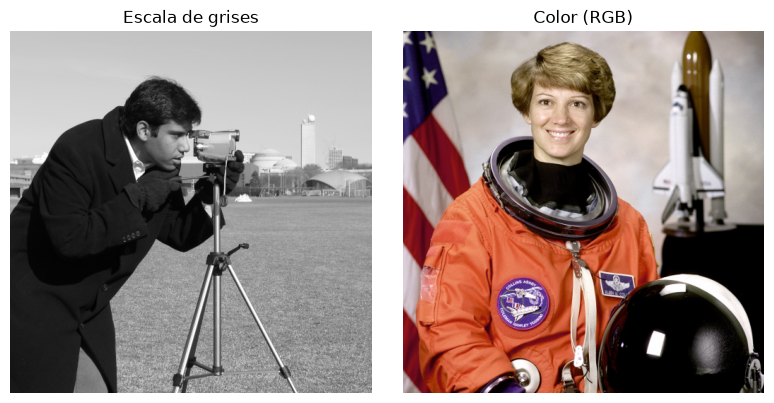

In [7]:
# Prueba rápida con imágenes incluidas en scikit-image
camara = data.camera()      # escala de grises, 512x512
astronauta = data.astronaut()  # color RGB, 512x512x3

print("Cámara     -> forma:", camara.shape, "| tipo:", camara.dtype)
print("Astronauta -> forma:", astronauta.shape, "| tipo:", astronauta.dtype)

mostrar([camara, astronauta], ["Escala de grises", "Color (RGB)"])

---
*Los temas del curso se agregan a continuación.*

---
# Tema 1: Histograma de una imagen

## 1.1 ¿Qué es un histograma?

El **histograma** de una imagen es una gráfica que indica **cuántos píxeles hay de cada nivel de intensidad**.

Para una imagen en escala de grises con $L$ niveles posibles ($r_k = 0, 1, \dots, L-1$):

$$
h(r_k) = n_k
$$

donde $n_k$ es el número de píxeles cuya intensidad es exactamente $r_k$.

- Eje horizontal: niveles de intensidad (0 = negro, $L-1$ = blanco).
- Eje vertical: cantidad de píxeles con esa intensidad.
- Para una imagen de **8 bits**: $L = 2^8 = 256$ niveles (0 a 255).

> 🔌 **Analogía con electrónica:** imagina que muestreas una señal con un ADC de 8 bits y guardas miles de muestras. Si cuentas cuántas veces salió cada código (0, 1, ..., 255), obtienes un histograma de **amplitudes**. En una imagen pasa lo mismo, solo que las muestras están en una cuadrícula 2D.

### Histograma normalizado

Si dividimos cada cuenta entre el total de píxeles $M \times N$ (filas × columnas):

$$
p(r_k) = \frac{n_k}{M \cdot N}, \qquad \sum_{k=0}^{L-1} p(r_k) = 1
$$

$p(r_k)$ es una **estimación de la probabilidad** de que un píxel elegido al azar tenga intensidad $r_k$. Es, en la práctica, una **función de densidad de probabilidad (PDF)** discreta.

### Histograma acumulado (CDF)

$$
c(r_k) = \sum_{j=0}^{k} p(r_j)
$$

Indica qué fracción de los píxeles tiene intensidad **menor o igual** a $r_k$. Siempre crece (o se mantiene) y termina en 1. La usaremos más adelante para la *ecualización de histograma*.

## 1.2 Cálculo paso a paso (a mano)

Tomemos una imagen pequeña de **4×4 píxeles** y **3 bits** ($L = 2^3 = 8$ niveles: 0 a 7):

$$
f = \begin{bmatrix}
0 & 1 & 1 & 2 \\
1 & 2 & 2 & 3 \\
2 & 3 & 3 & 7 \\
2 & 3 & 6 & 7
\end{bmatrix}
$$

**Algoritmo:**
1. Crear un arreglo de contadores con $L$ posiciones, todas en cero.
2. Recorrer la imagen píxel por píxel.
3. Por cada píxel con valor $r$, sumar 1 al contador en la posición $r$.
4. (Opcional) Dividir entre $M \cdot N = 16$ para normalizar.

**Resultado del conteo:**

| $r_k$ | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 |
|---|---|---|---|---|---|---|---|---|
| $n_k$ | 1 | 3 | 5 | 4 | 0 | 0 | 1 | 2 |
| $p(r_k)$ | 0.0625 | 0.1875 | 0.3125 | 0.25 | 0 | 0 | 0.0625 | 0.125 |
| $c(r_k)$ | 0.0625 | 0.25 | 0.5625 | 0.8125 | 0.8125 | 0.8125 | 0.875 | 1.0 |

Comprobación: $1+3+5+4+0+0+1+2 = 16$ píxeles ✔️

Ahora hagamos lo mismo en Python.

Imagen f:
 [[0 1 1 2]
 [1 2 2 3]
 [2 3 3 7]
 [2 3 6 7]]
Tamaño: 4x4 = 16 píxeles


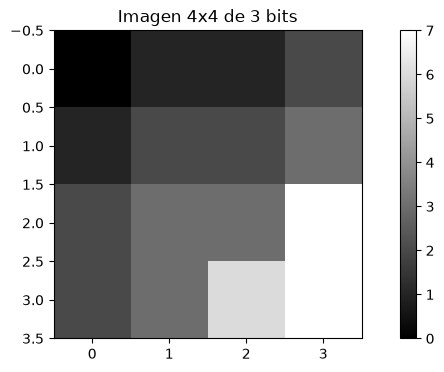

In [8]:
# Imagen de ejemplo: 4x4 píxeles, 3 bits (valores de 0 a 7)
f = np.array([[0, 1, 1, 2],
              [1, 2, 2, 3],
              [2, 3, 3, 7],
              [2, 3, 6, 7]], dtype=np.uint8)


# Visualizamos la matriz como imagen (vmin/vmax fijan la escala 0..L-1)


In [9]:
# PASO 1: arreglo de contadores, uno por cada nivel de intensidad


# PASO 2 y 3: recorrer cada píxel y sumar 1 en la posición de su valor


Histograma h(r_k): [1 3 5 4 0 0 1 2]
Suma de cuentas  : 16 (debe ser 16 )


r_k : [0 1 2 3 4 5 6 7]
p   : [0.0625 0.1875 0.3125 0.25   0.     0.     0.0625 0.125 ]
c   : [0.0625 0.25   0.5625 0.8125 0.8125 0.8125 0.875  1.    ]


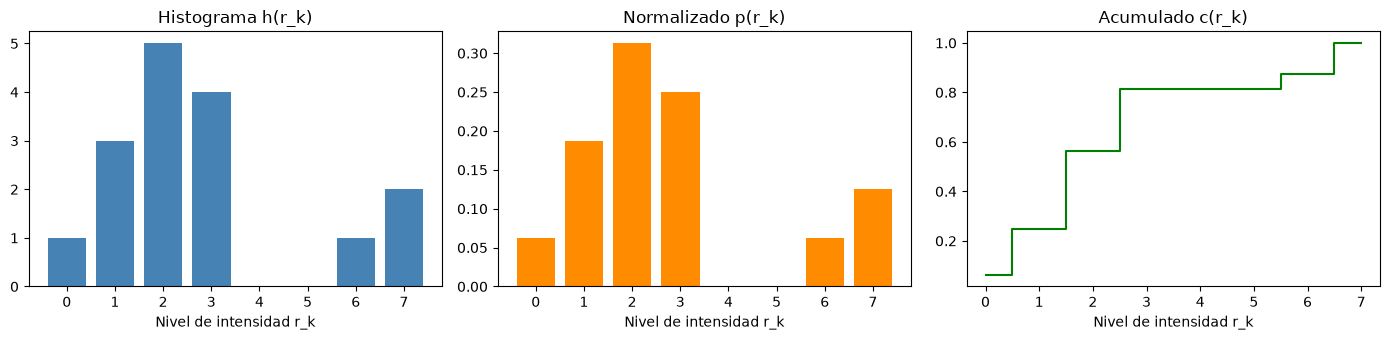

In [10]:
# PASO 4: histograma normalizado (PDF) e histograma acumulado (CDF)

# suma acumulada: c[k] = p[0] + p[1] + ... + p[k]

print("r_k :", np.arange(L))
print("p   :", np.round(p, 4))
print("c   :", np.round(c, 4))

fig, ax = plt.subplots(1, 3, figsize=(14, 3.5))
ax[0].bar(range(L), h, color="steelblue");  ax[0].set_title("Histograma h(r_k)")
ax[1].bar(range(L), p, color="darkorange"); ax[1].set_title("Normalizado p(r_k)")
ax[2].step(range(L), c, where="mid", color="green"); ax[2].set_title("Acumulado c(r_k)")
for a in ax:
    a.set_xlabel("Nivel de intensidad r_k")
    a.set_xticks(range(L))
plt.tight_layout()
plt.show()

### Verificación con funciones de NumPy

El doble `for` es ideal para **entender** el algoritmo, pero NumPy ya trae funciones que hacen lo mismo:

- `np.bincount(f.ravel(), minlength=L)`: cuenta cuántas veces aparece cada entero.
- `np.histogram(f, bins=L, range=(0, L))`: función general de histogramas.

`f.ravel()` "aplana" la matriz en un vector 1D (todas las filas una tras otra).

In [11]:


print("Manual     :", h)
print("bincount   :", h_bincount)
print("histogram  :", h_numpy)
print("¿Iguales?  :", np.array_equal(h, h_bincount) and np.array_equal(h, h_numpy))

Manual     : [1 3 5 4 0 0 1 2]
bincount   : [1 3 5 4 0 0 1 2]
histogram  : [1 3 5 4 0 0 1 2]
¿Iguales?  : True


## 1.3 Histograma de una imagen real (8 bits)

Ahora usamos la imagen `camara` (512×512, 256 niveles). Compararemos tres formas de calcularlo:

1. Nuestro **doble `for`** (lento, pero es el algoritmo "puro").
2. **NumPy** (`np.bincount`), vectorizado.
3. **OpenCV** (`cv2.calcHist`), la función más usada en la práctica.

Sintaxis de `cv2.calcHist`:
```python
cv2.calcHist([imagen], [canal], mascara, [num_bins], [rango_min, rango_max])
```

In [12]:
import time

img = camara           # imagen en escala de grises, uint8

# 1) Algoritmo manual

# 2) NumPy

# 3) OpenCV (devuelve un arreglo de forma (256, 1) en float32)


print(f"Manual : {t_manual*1000:8.2f} ms")
print(f"NumPy  : {t_np*1000:8.2f} ms")
print(f"OpenCV : {t_cv*1000:8.2f} ms")
print("¿Los tres iguales?", np.array_equal(h_manual, h_np) and np.array_equal(h_np, h_cv))

Manual :   203.65 ms
NumPy  :     1.77 ms
OpenCV :   168.62 ms
¿Los tres iguales? True


Como ves, el resultado es el mismo, pero las funciones optimizadas son **cientos de veces más rápidas**: están escritas en C y no recorren los píxeles con un bucle de Python.

Definimos una función auxiliar que muestra una imagen junto a su histograma. La usaremos mucho en este tema y en los siguientes.

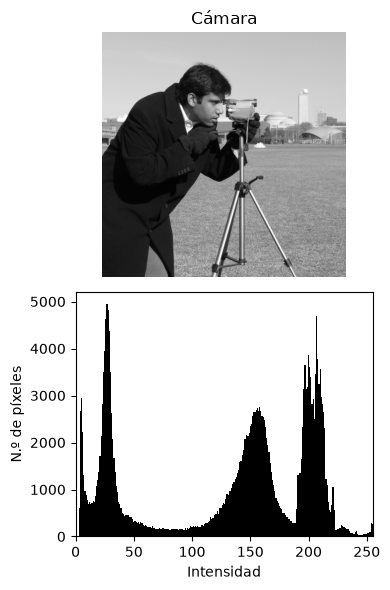

In [13]:
def mostrar_con_histograma(imagenes, titulos=None):
    # Muestra cada imagen (fila superior) con su histograma (fila inferior)
    if not isinstance(imagenes, (list, tuple)):
        imagenes = [imagenes]
    n = len(imagenes)
    fig, ax = plt.subplots(2, n, figsize=(4 * n, 6), squeeze=False)
    for k, im in enumerate(imagenes):
        ax[0, k].imshow(im, cmap="gray", vmin=0, vmax=255)
        ax[0, k].axis("off")
        if titulos:
            ax[0, k].set_title(titulos[k])
        hist = np.bincount(im.ravel(), minlength=256)
        ax[1, k].bar(range(256), hist, width=1.0, color="black")
        ax[1, k].set_xlim(0, 255)
        ax[1, k].set_xlabel("Intensidad")
    ax[1, 0].set_ylabel("N.º de píxeles")
    plt.tight_layout()
    plt.show()

mostrar_con_histograma(camara, ["Cámara"])

Suma de p(r_k): 1.0
Intensidad media: 129.06072616577148 | con np.mean: 129.06072616577148


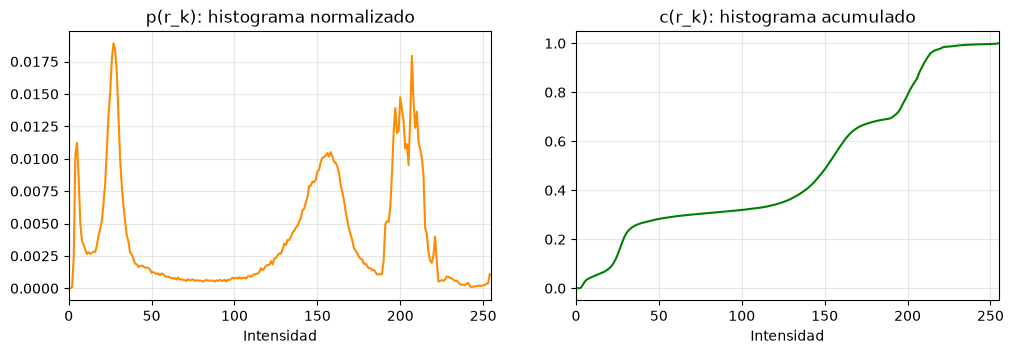

In [14]:
# Histograma normalizado y acumulado de la imagen real


print("Suma de p(r_k):", p.sum())            # debe dar 1
print("Intensidad media:", (np.arange(L) * p).sum(), "| con np.mean:", img.mean())

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
ax[0].plot(p, color="darkorange"); ax[0].set_title("p(r_k): histograma normalizado")
ax[1].plot(c, color="green");      ax[1].set_title("c(r_k): histograma acumulado")
for a in ax:
    a.set_xlabel("Intensidad"); a.set_xlim(0, 255); a.grid(alpha=0.3)
plt.show()

> 📌 Nota que la **media** de la imagen se puede calcular desde el histograma normalizado: $\mu = \sum_k r_k \, p(r_k)$. Es la misma fórmula del valor esperado de una variable aleatoria discreta.

## 1.4 ¿Cómo se interpreta un histograma?

La forma del histograma nos dice mucho sobre la imagen **sin necesidad de verla**:

| Forma del histograma | La imagen es... |
|---|---|
| Concentrado a la **izquierda** | Oscura (subexpuesta) |
| Concentrado a la **derecha** | Clara (sobreexpuesta) |
| **Angosto**, en el centro | De bajo contraste (grisácea, "lavada") |
| **Extendido** en todo el rango | De buen contraste |

Generemos las cuatro versiones a partir de `camara`:

In [ ]:
# Trabajamos en float para evitar desbordamientos y al final volvemos a uint8
x = camara.astype(np.float64)

# comprime hacia 0   
# comprime hacia 255
# rango angosto en el centro

mostrar_con_histograma([oscura, clara, bajo_contraste, camara],
                       ["Oscura", "Clara", "Bajo contraste", "Original"])

## 1.5 El histograma NO guarda información espacial

El histograma solo cuenta **cuántos** píxeles hay de cada valor, no **dónde** están. Por eso, imágenes muy diferentes pueden tener exactamente el mismo histograma.

Prueba: desordenamos todos los píxeles de la imagen al azar.

In [ ]:


print("¿Histogramas idénticos?",
      np.array_equal(np.bincount(camara.ravel(), minlength=256),
                     np.bincount(revuelta.ravel(), minlength=256)))

## 1.6 Histograma de una imagen a color

Una imagen RGB tiene **tres canales** y cada uno es una imagen en escala de grises. Se calcula un histograma **por canal**.

In [ ]:
colores = ("red", "green", "blue")
nombres = ("Rojo (R)", "Verde (G)", "Azul (B)")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(astronauta); ax[0].axis("off"); ax[0].set_title("Astronauta (RGB)")

for canal, (col, nom) in enumerate(zip(colores, nombres)):
    hist = cv2.calcHist([astronauta], [canal], None, [256], [0, 256]).ravel()
    ax[1].plot(hist, color=col, label=nom)

ax[1].set_xlim(0, 255); ax[1].set_xlabel("Intensidad"); ax[1].legend(); ax[1].grid(alpha=0.3)
ax[1].set_title("Histograma por canal")
plt.tight_layout()
plt.show()

> ⚠️ Si la imagen la cargas con `cv2.imread`, el canal 0 es **azul**, no rojo (orden BGR).

---
## 1.7 Ejercicios

Para cada ejercicio, **primero escribe tu predicción** (en papel o en una celda de texto) y luego ejecuta el código para comprobarla.

### Ejercicio 1: Histograma a mano
Calcula a mano $h(r_k)$, $p(r_k)$ y $c(r_k)$ para esta imagen de 3 bits ($L=8$) y luego completa el código para verificar.

$$
g = \begin{bmatrix}
7 & 7 & 6 & 5 & 5 \\
6 & 5 & 5 & 4 & 4 \\
5 & 4 & 4 & 4 & 3 \\
4 & 4 & 3 & 3 & 0 \\
4 & 3 & 3 & 1 & 0
\end{bmatrix}
$$

¿La imagen es más bien oscura o clara?

In [ ]:
g = np.array([[7, 7, 6, 5, 5],
              [6, 5, 5, 4, 4],
              [5, 4, 4, 4, 3],
              [4, 4, 3, 3, 0],
              [4, 3, 3, 1, 0]], dtype=np.uint8)
L = 8

# TODO: calcula el histograma con un doble for (sin usar np.bincount)
h_g = np.zeros(L, dtype=int)
# ... tu código aquí ...

# TODO: calcula p_g (normalizado) y c_g (acumulado)
# p_g = ...
# c_g = ...

print("h:", h_g)
# Verificación automática:
print("¿Correcto?", np.array_equal(h_g, np.bincount(g.ravel(), minlength=L)))

### Ejercicio 2: Sumar brillo y el desbordamiento de `uint8`

Queremos aclarar la imagen sumando 100 a cada píxel.

**Predice:** ¿cómo se moverá el histograma?

Ejecuta la celda y compara los dos métodos. ¿Por qué el método A produce una imagen extraña?

*Pista:* en `uint8`, ¿cuánto vale `250 + 100`? Piensa en un contador binario de 8 bits.

In [ ]:
# Método A: suma directa en uint8 (¡cuidado!)
a = camara + np.uint8(100)

# Método B: suma con saturación (recorta a 255)
b = cv2.add(camara, 100)                # OpenCV satura automáticamente
# Equivalente con NumPy: np.clip(camara.astype(int) + 100, 0, 255).astype(np.uint8)

mostrar_con_histograma([camara, a, b], ["Original", "A: uint8 directo", "B: con saturación"])

print("250 + 100 en uint8 =", np.uint8(250) + np.uint8(100))

**Preguntas:**
1. En el método B, ¿por qué aparece un pico muy alto justo en 255?
2. En el método A, ¿a dónde "fueron" los píxeles que eran muy claros?
3. ¿Qué operación aritmética describe lo que pasa en A? (Pista: módulo).

### Ejercicio 3: Multiplicar por una constante (contraste)

Multiplica la imagen por $\alpha = 0.5$ y luego por $\alpha = 1.5$ (con saturación).

**Predice:** ¿el histograma se desplaza, se estira o se comprime?

In [ ]:
alfa1, alfa2 = 0.5, 1.5

# TODO: completa usando np.clip para saturar entre 0 y 255
m1 = np.clip(camara.astype(np.float64) * alfa1, 0, 255).astype(np.uint8)
m2 = None   # ... tu código aquí (alfa2) ...

mostrar_con_histograma([camara, m1] + ([m2] if m2 is not None else []),
                       ["Original", f"x {alfa1}", f"x {alfa2}"])

### Ejercicio 4: Negativo de una imagen

El negativo se obtiene con $s = (L-1) - r = 255 - r$.

**Predice:** ¿qué le pasa al histograma? Dibuja un bosquejo antes de ejecutar.

In [ ]:
negativo = 255 - camara

mostrar_con_histograma([camara, negativo], ["Original", "Negativo"])

# Comprobación: el histograma del negativo es el original "al revés"
h_orig = np.bincount(camara.ravel(), minlength=256)
h_neg = np.bincount(negativo.ravel(), minlength=256)
print("¿h_neg es h_orig invertido?", np.array_equal(h_neg, h_orig[::-1]))

### Ejercicio 5: Cuantización (conexión con el ADC)

Reducir el número de bits de una imagen es como usar un **ADC de menor resolución**. Con $b$ bits solo hay $2^b$ niveles.

Completa la función y prueba con $b = 4, 2, 1$.

**Predice:** ¿cuántas barras distintas de cero tendrá el histograma en cada caso? ¿Desde cuántos bits empiezas a notar "escalones" (*falso contorno*) en la imagen?

In [ ]:
def cuantizar(imagen, bits):
    # Reduce una imagen de 8 bits a 'bits' bits (manteniendo la escala 0..255)
    paso = 256 // (2 ** bits)         # ancho de cada intervalo de cuantización
    return (imagen // paso) * paso    # división entera -> índice del nivel -> valor

cuantizadas = [cuantizar(camara, b) for b in (8, 4, 2, 1)]
mostrar_con_histograma(cuantizadas, ["8 bits", "4 bits", "2 bits", "1 bit"])

for b, q in zip((8, 4, 2, 1), cuantizadas):
    print(f"{b} bits -> niveles distintos usados: {len(np.unique(q))}")

### Ejercicio 6: Mismo histograma, imágenes diferentes

Crea **dos imágenes de 8×8** que tengan **exactamente el mismo histograma** pero que se vean distintas. Por ejemplo:
- Imagen A: mitad izquierda negra (0) y mitad derecha blanca (255).
- Imagen B: un tablero de ajedrez.

Verifica con `np.bincount` que sus histogramas son iguales.

In [ ]:
# Imagen A: mitad negra / mitad blanca
A = np.zeros((8, 8), dtype=np.uint8)
A[:, 4:] = 255

# TODO: Imagen B, tablero de ajedrez
# Pista: (np.indices((8, 8)).sum(axis=0) % 2) da 0 y 1 alternados
B = None  # ... tu código aquí ...

if B is not None:
    mostrar([A, B], ["A", "B"])
    print("¿Mismo histograma?",
          np.array_equal(np.bincount(A.ravel(), minlength=256),
                         np.bincount(B.ravel(), minlength=256)))

### Ejercicio 7 (reto): Leer la CDF

Usando el histograma acumulado $c(r_k)$ de `camara`, responde:
1. ¿Qué porcentaje de píxeles tiene intensidad **menor o igual a 100**?
2. ¿Cuál es la intensidad **mediana** (el menor $r_k$ tal que $c(r_k) \geq 0.5$)?

Compara tu respuesta 2 con `np.median(camara)`.

In [ ]:
p_cam = np.bincount(camara.ravel(), minlength=256) / camara.size
c_cam = np.cumsum(p_cam)

# TODO 1: porcentaje de píxeles con intensidad <= 100
# porcentaje = ...

# TODO 2: mediana a partir de la CDF (pista: np.argmax(c_cam >= 0.5))
# mediana = ...

print("np.median:", np.median(camara))

<details>
<summary><b>👀 Soluciones (haz clic solo después de intentarlo)</b></summary>

**Ej. 1:** $h = [2, 1, 0, 5, 8, 5, 2, 2]$ (suma 25 ✔️). La mayoría de píxeles está en los niveles 3–5 (de 0–7): la imagen es de brillo medio y ligeramente clara.

**Ej. 2:** (1) Todos los píxeles que superaban 255 quedan recortados en 255 y se acumulan ahí. (2) Dieron "la vuelta" y quedaron cerca de 0 (se ven oscuros). (3) El resultado es $(r + 100) \bmod 256$, igual que un contador de 8 bits que se desborda.

**Ej. 3:** `m2 = np.clip(camara.astype(np.float64) * alfa2, 0, 255).astype(np.uint8)`. Con $\alpha<1$ el histograma se **comprime** hacia 0 (menos contraste); con $\alpha>1$ se **estira** (más contraste) y aparece saturación en 255.

**Ej. 4:** El histograma queda reflejado en espejo alrededor de 127.5.

**Ej. 5:** 256, 16, 4 y 2 niveles (como máximo; puede haber menos si algún intervalo está vacío). El falso contorno se vuelve evidente alrededor de 4 bits o menos.

**Ej. 6:** `B = (np.indices((8, 8)).sum(axis=0) % 2 * 255).astype(np.uint8)`. Ambas tienen 32 píxeles en 0 y 32 en 255.

**Ej. 7:** `porcentaje = c_cam[100] * 100` y `mediana = np.argmax(c_cam >= 0.5)`.
</details>

---
# Tema 2: Ecualización de histograma

> En este tema **todo el procesamiento se hace con OpenCV (`cv2`)**. Matplotlib solo se usa para graficar.

### Preparación del tema

Para que este tema funcione **sin ejecutar el Tema 1**, la siguiente celda vuelve a crear las funciones e imágenes que se usan aquí. Solo necesitas haber ejecutado antes la **sección 0** (importaciones, `mostrar()` e imágenes de prueba).

Usamos `cv2.convertScaleAbs(img, alpha, beta)`, que calcula $s = |\alpha \cdot r + \beta|$ y **satura** el resultado al rango 0–255:
- $\alpha < 1$ comprime el histograma (menos contraste).
- $\beta$ lo desplaza (más o menos brillo).

In [ ]:
# Imágenes de prueba (las mismas del Tema 1, ahora generadas con cv2)
oscura         = cv2.convertScaleAbs(camara, alpha=0.35, beta=0)     # comprimida hacia 0
clara          = cv2.convertScaleAbs(camara, alpha=0.35, beta=166)   # comprimida hacia 255
bajo_contraste = cv2.convertScaleAbs(camara, alpha=0.25, beta=96)    # rango angosto al centro


def mostrar_con_histograma(imagenes, titulos=None):
    # Muestra cada imagen (fila superior) con su histograma (fila inferior)
    if not isinstance(imagenes, (list, tuple)):
        imagenes = [imagenes]
    n = len(imagenes)
    fig, ax = plt.subplots(2, n, figsize=(4 * n, 6), squeeze=False)
    for k, im in enumerate(imagenes):
        ax[0, k].imshow(im, cmap="gray", vmin=0, vmax=255)
        ax[0, k].axis("off")
        if titulos:
            ax[0, k].set_title(titulos[k])
        hist = cv2.calcHist([im], [0], None, [256], [0, 256]).ravel()
        ax[1, k].bar(range(256), hist, width=1.0, color="black")
        ax[1, k].set_xlim(0, 255)
        ax[1, k].set_xlabel("Intensidad")
    ax[1, 0].set_ylabel("N.º de píxeles")
    plt.tight_layout()
    plt.show()


mostrar_con_histograma([oscura, clara, bajo_contraste], ["Oscura", "Clara", "Bajo contraste"])

## 2.1 Idea

En el Tema 1 vimos que una imagen de **bajo contraste** tiene el histograma **concentrado** en una zona angosta. La ecualización busca **repartir** los niveles de gris en todo el rango $[0, L-1]$, para que el histograma de salida quede lo más **uniforme (plano)** posible.

Se aplica una transformación punto a punto:

$$
s = T(r)
$$

donde $r$ es la intensidad de entrada y $s$ la de salida. $T$ debe ser:
1. **Monótona creciente**: un píxel más oscuro que otro sigue siéndolo después (no se invierte el orden de los tonos).
2. Que cumpla $0 \le T(r) \le L-1$: la salida queda dentro del rango válido.

### ¿Qué función $T$ usar? ¡La CDF!

Un resultado de probabilidad dice que si $r$ es una variable aleatoria con CDF $c(r)$, entonces la variable $s = c(r)$ tiene **distribución uniforme** en $[0,1]$. Por eso, escalando al rango de la imagen:

$$
\boxed{\,s_k = T(r_k) = (L-1)\sum_{j=0}^{k} p(r_j) = (L-1)\, c(r_k)\,}
$$

> 🔌 **Analogía:** es como un **compansor** (compresor/expansor) en comunicaciones. Los rangos de amplitud donde hay muchas muestras se "expanden" y ocupan más niveles; donde hay pocas muestras se "comprimen".

### Fórmula que usa OpenCV

`cv2.equalizeHist` usa una versión que garantiza que el nivel más oscuro presente quede en 0 y el más claro en 255:

$$
s_k = \operatorname{round}\!\left( \frac{\text{cdf}(r_k) - \text{cdf}_{\min}}{M N - \text{cdf}_{\min}} \cdot (L-1) \right)
$$

- $\text{cdf}(r_k)$: histograma acumulado **en cuentas** (no normalizado).
- $\text{cdf}_{\min}$: primer valor distinto de cero del acumulado.
- $M N$: número total de píxeles.

⚠️ **En el caso discreto el histograma resultante NO es perfectamente plano.** La ecualización solo puede **mover** barras completas (todos los píxeles con el mismo $r_k$ van al mismo $s_k$). Nunca **divide** una barra en varias.

## 2.2 Ejemplo a mano

Usamos una imagen de 4×4 y 8 bits, de **bajo contraste**: todos sus valores están entre 100 y 107.

$$
f = \begin{bmatrix}
100 & 101 & 101 & 102 \\
101 & 102 & 102 & 103 \\
102 & 103 & 103 & 107 \\
102 & 103 & 106 & 107
\end{bmatrix}, \qquad MN = 16,\; L-1 = 255
$$

| $r_k$ | 100 | 101 | 102 | 103 | 104 | 105 | 106 | 107 |
|---|---|---|---|---|---|---|---|---|
| $h(r_k)$ | 1 | 3 | 5 | 4 | 0 | 0 | 1 | 2 |
| $\text{cdf}(r_k)$ | 1 | 4 | 9 | 13 | 13 | 13 | 14 | 16 |
| $\text{cdf} - \text{cdf}_{\min}$ | 0 | 3 | 8 | 12 | 12 | 12 | 13 | 15 |
| $s_k = \frac{\text{cdf}-1}{15}\cdot 255$ | **0** | **51** | **136** | **204** | – | – | **221** | **255** |

($\text{cdf}_{\min} = 1$; los niveles 104 y 105 no tienen píxeles, así que no importa a dónde se mapeen).

**Resultado:** el rango pasó de $[100, 107]$ (8 niveles) a $[0, 255]$. ¡El contraste aumentó muchísimo!

$$
g = \begin{bmatrix}
0 & 51 & 51 & 136 \\
51 & 136 & 136 & 204 \\
136 & 204 & 204 & 255 \\
136 & 204 & 221 & 255
\end{bmatrix}
$$

Entrada f:
 [[100 101 101 102]
 [101 102 102 103]
 [102 103 103 107]
 [102 103 106 107]]

Ecualizada g:
 [[  0  51  51 136]
 [ 51 136 136 204]
 [136 204 204 255]
 [136 204 221 255]]


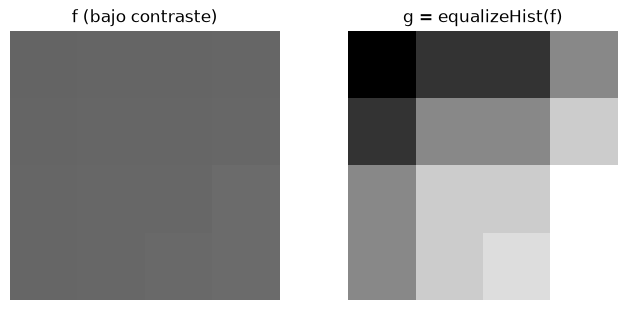

In [15]:
# Creamos la imagen del ejemplo y la ecualizamos con OpenCV
# (np.array solo se usa para escribir los datos; el procesamiento es con cv2)
f = np.array([[100, 101, 101, 102],
              [101, 102, 102, 103],
              [102, 103, 103, 107],
              [102, 103, 106, 107]], dtype=np.uint8)

print("Entrada f:\n", f)
print("\nEcualizada g:\n", g)

fig, ax = plt.subplots(1, 2, figsize=(8, 3.5))
ax[0].imshow(f, cmap="gray", vmin=0, vmax=255); ax[0].set_title("f (bajo contraste)")
ax[1].imshow(g, cmap="gray", vmin=0, vmax=255); ax[1].set_title("g = equalizeHist(f)")
for a in ax: a.axis("off")
plt.show()

> Nota que `f` se ve casi como un cuadro gris uniforme (todos los valores están entre 100 y 107). Después de ecualizar, las diferencias son claramente visibles.

## 2.3 Paso a paso con una imagen real

Para entender qué hace `cv2.equalizeHist` por dentro, construiremos la transformación nosotros mismos, usando solo funciones de OpenCV y bucles sencillos de Python:

1. `cv2.calcHist` → histograma $h(r_k)$.
2. Bucle de Python → histograma acumulado $\text{cdf}(r_k)$.
3. Aplicar la fórmula → **tabla de consulta** (*LUT, Look-Up Table*) de 256 entradas: `lut[r] = s`.
4. `cv2.LUT` → reemplaza cada píxel $r$ por `lut[r]`.

> 🔌 Una **LUT** es exactamente lo que harías en hardware (una memoria ROM o una FPGA): la dirección es el valor de entrada y el dato guardado es el valor de salida. Es muy rápida porque no hay que calcular nada por píxel, solo leer la memoria.

Usaremos la imagen `bajo_contraste` que generamos en el Tema 1.

In [17]:
img = obscura               
# imagen de 8 bits, un canal

# PASO 1: histograma con OpenCV (arreglo de 256 valores float32)

# PASO 2: histograma acumulado (en cuentas)

# cdf_min: primer valor distinto de cero

print("Rango de intensidades presente:", cv2.minMaxLoc(img)[:2])
print("Total de píxeles MN =", MN, "| cdf[255] =", cdf[255], "| cdf_min =", cdf_min)

Rango de intensidades presente: (100.0, 107.0)
Total de píxeles MN = 16 | cdf[255] = 16.0 | cdf_min = 1.0


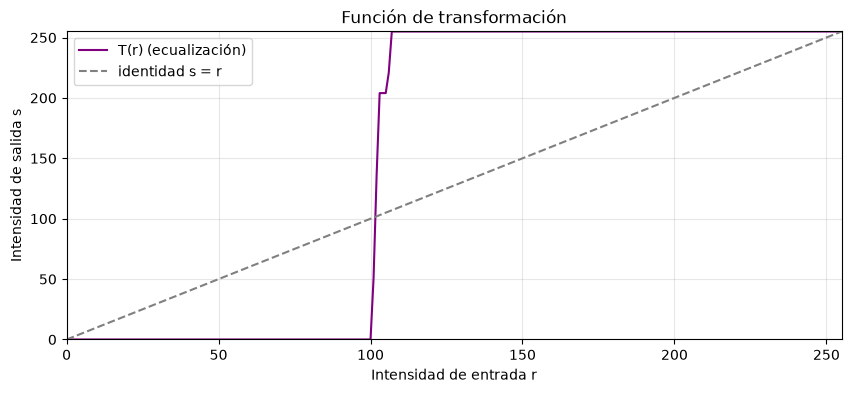

In [18]:
# PASO 3: construir la LUT con la fórmula de OpenCV

# Graficamos la transformación s = T(r)
plt.plot(range(256), lut, color="purple", label="T(r) (ecualización)")
plt.plot([0, 255], [0, 255], "--", color="gray", label="identidad s = r")
plt.xlabel("Intensidad de entrada r"); plt.ylabel("Intensidad de salida s")
plt.title("Función de transformación"); plt.legend(); plt.grid(alpha=0.3)
plt.xlim(0, 255); plt.ylim(0, 255)
plt.show()

La curva tiene la **forma de la CDF**. Donde hay muchos píxeles (zona central), la pendiente es grande: esos niveles se **separan** entre sí. Fuera de esa zona, la curva es plana porque no hay píxeles.

Píxeles diferentes entre nuestro método y equalizeHist: 0


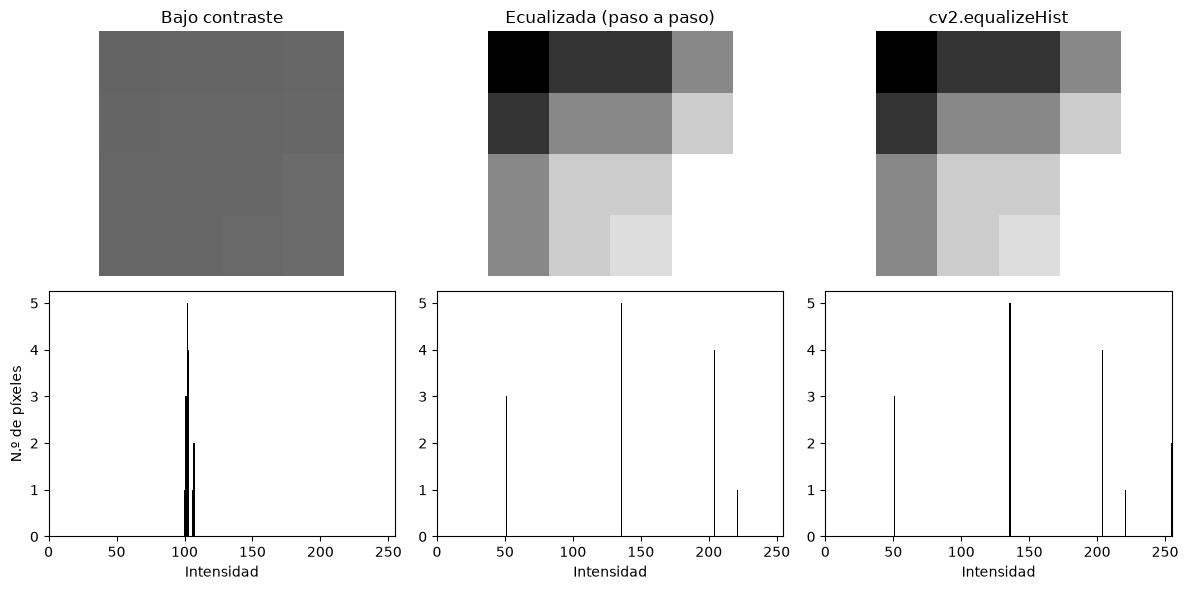

In [19]:
# PASO 4: aplicar la LUT a toda la imagen


# Comparamos con la función de OpenCV

print("Píxeles diferentes entre nuestro método y equalizeHist:", cv2.countNonZero(diferencia))

mostrar_con_histograma([img, eq_manual, eq_cv],
                       ["Bajo contraste", "Ecualizada (paso a paso)", "cv2.equalizeHist"])

## 2.4 Antes y después: el histograma acumulado se vuelve una recta

Si el histograma de salida fuera perfectamente plano, su CDF sería una **línea recta** de 0 a 1. Veamos qué tan cerca queda con las imágenes oscura, clara y de bajo contraste del Tema 1.

In [20]:
def cdf_normalizada(imagen):
    # Histograma acumulado normalizado (0 a 1) usando cv2.calcHist
    h = cv2.calcHist([imagen], [0], None, [256], [0, 256]).ravel()
    acumulado, total = [], 0.0
    for v in h:
        total += v
        acumulado.append(total)
    return [a / total for a in acumulado]

casos = {"Oscura": oscura, "Clara": clara, "Bajo contraste": bajo_contraste}

for nombre, im in casos.items():
    eq = cv2.equalizeHist(im)
    mostrar_con_histograma([im, eq], [nombre, nombre + " ecualizada"])

    plt.figure(figsize=(6, 3))
    plt.plot(cdf_normalizada(im), label="CDF original")
    plt.plot(cdf_normalizada(eq), label="CDF ecualizada")
    plt.plot([0, 255], [0, 1], "--", color="gray", label="CDF uniforme ideal")
    plt.title(f"{nombre}: histograma acumulado"); plt.xlim(0, 255)
    plt.legend(); plt.grid(alpha=0.3)
    plt.show()

NameError: name 'oscura' is not defined

**Observa:**
- Las tres imágenes quedan **muy parecidas** después de ecualizar: la ecualización no depende del brillo original, sino de **cómo están ordenados** los niveles.
- El histograma ecualizado tiene **huecos** (barras separadas). Son los niveles que "saltó" la transformación, porque no se pueden crear niveles nuevos.
- La CDF ecualizada sigue muy de cerca a la recta ideal.

## 2.5 Imágenes a color

`cv2.equalizeHist` solo acepta imágenes de **un canal**. Para una imagen a color hay dos opciones:

| Método | Resultado |
|---|---|
| ❌ Ecualizar R, G y B por separado | Cada canal cambia de forma distinta → **los colores se alteran** |
| ✅ Pasar a un espacio con canal de **luminancia** (YCrCb), ecualizar solo **Y** y volver a RGB | Mejora el contraste **sin cambiar los colores** |

En **YCrCb**: Y = luminancia (brillo), Cr y Cb = información de color (crominancia). Es el mismo principio de la señal de TV analógica y de JPEG.

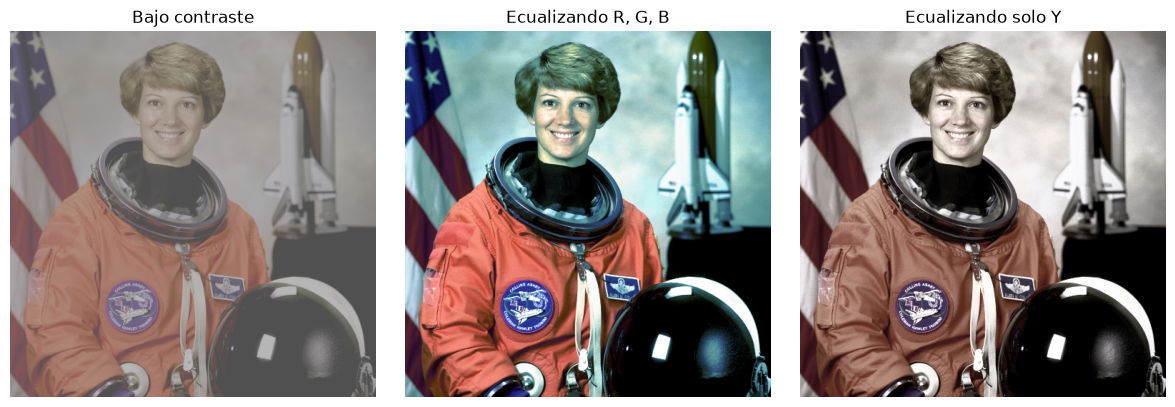

In [21]:
# Imagen a color de bajo contraste: s = 0.4*r + 80 (convertScaleAbs satura a 0..255)

# [NO] Método 1: ecualizar cada canal por separado

# [OK] Método 2: ecualizar solo la luminancia

mostrar([color_bc, eq_rgb, eq_y],
        ["Bajo contraste", "Ecualizando R, G, B", "Ecualizando solo Y"])

> ⚠️ Si la imagen viene de `cv2.imread` (orden BGR), usa `cv2.COLOR_BGR2YCrCb` y `cv2.COLOR_YCrCb2BGR`.

## 2.6 Limitaciones y CLAHE (ecualización adaptativa)

La ecualización **global** usa un solo histograma para toda la imagen. Esto trae problemas:
- Si la imagen tiene zonas muy oscuras y otras muy claras, una sola transformación no sirve bien para ambas.
- **Amplifica el ruido** en zonas casi uniformes (cielo, fondo), porque separa niveles que eran casi iguales.

**CLAHE** (*Contrast Limited Adaptive Histogram Equalization*) resuelve esto:
1. **Adaptativa:** divide la imagen en bloques (*tiles*), por ejemplo 8×8, y ecualiza cada bloque con su propio histograma.
2. **Contraste limitado:** antes de ecualizar, **recorta** las barras del histograma que superan un límite (`clipLimit`) y reparte el exceso entre todos los niveles. Así la pendiente de $T(r)$ no puede crecer demasiado y el ruido no se amplifica tanto.
3. Interpola entre bloques vecinos para que no se noten los bordes.

```python
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
salida = clahe.apply(imagen)
```

Probemos con la imagen `moon` (superficie lunar, de muy bajo contraste).

In [1]:
luna = data.moon()      # 512x512, uint8, escala de grises

mostrar_con_histograma([luna, eq_global, eq_clahe],
                       ["Original", "Ecualización global", "CLAHE (clip=2, 8x8)"])

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


NameError: name 'data' is not defined

Observa que la ecualización global exagera el contraste y resalta el ruido del fondo. CLAHE realza los detalles locales (cráteres) de forma más natural.

---
## 2.7 Ejercicios

Recuerda: **primero predice**, luego ejecuta.

### Ejercicio 1: Ecualización a mano

Usa la imagen $g$ de 5×5 del Ejercicio 1 del Tema 1 (niveles 0 a 7, guardada en 8 bits). Su histograma es $h = [2, 1, 0, 5, 8, 5, 2, 2]$.

Calcula a mano, con la fórmula de OpenCV, el nivel de salida $s_k$ para cada $r_k$ y completa la lista `s_mano`. Después verifica con `cv2.equalizeHist`.

In [ ]:
g5 = np.array([[7, 7, 6, 5, 5],
               [6, 5, 5, 4, 4],
               [5, 4, 4, 4, 3],
               [4, 4, 3, 3, 0],
               [4, 3, 3, 1, 0]], dtype=np.uint8)

# TODO: escribe tus resultados a mano para r = 0, 1, ..., 7
s_mano = [None] * 8

g5_eq = cv2.equalizeHist(g5)
# Tabla r -> s según OpenCV (solo para niveles presentes en la imagen)
tabla = {int(g5[i, j]): int(g5_eq[i, j]) for i in range(5) for j in range(5)}
print("OpenCV  r -> s:", dict(sorted(tabla.items())))
print("A mano        :", {r: s_mano[r] for r in sorted(tabla)})

### Ejercicio 2: ¿Ecualizar dos veces?

**Predice:** si ecualizas una imagen que ya está ecualizada, ¿cambia algo?

Ejecuta y cuenta cuántos píxeles cambian.

In [ ]:
eq1 = cv2.equalizeHist(camara)
eq2 = cv2.equalizeHist(eq1)

print("Píxeles que cambian de la 1.ª a la 2.ª ecualización:",
      cv2.countNonZero(cv2.absdiff(eq1, eq2)), "de", camara.size)

mostrar_con_histograma([camara, eq1, eq2], ["Original", "Ecualizada 1 vez", "Ecualizada 2 veces"])

**Pregunta:** ¿por qué cambian tan pocos píxeles (o ninguno)? Piensa en qué forma tiene la CDF de una imagen ya ecualizada.

### Ejercicio 3: Ecualizar no crea información

Cuantiza `camara` a **2 bits** (4 niveles) y luego ecualízala.

**Predice:** ¿cuántos niveles distintos tendrá la imagen ecualizada? ¿Desaparecen los "escalones" (falso contorno)?

In [ ]:
# Cuantización a 2 bits con una LUT: cada nivel r pasa a (r // 64) * 64
# (np.array solo se usa para escribir la tabla; se aplica con cv2.LUT)
lut_2bits = np.array([(r // 64) * 64 for r in range(256)], dtype=np.uint8)
q2 = cv2.LUT(camara, lut_2bits)

q2_eq = cv2.equalizeHist(q2)

h_q2 = cv2.calcHist([q2], [0], None, [256], [0, 256])
h_q2_eq = cv2.calcHist([q2_eq], [0], None, [256], [0, 256])
print("Niveles distintos antes :", cv2.countNonZero(h_q2))
print("Niveles distintos después:", cv2.countNonZero(h_q2_eq))

mostrar_con_histograma([q2, q2_eq], ["2 bits", "2 bits ecualizada"])

### Ejercicio 4: Parámetros de CLAHE

Modifica `clipLimit` y `tileGridSize` y observa el efecto sobre `luna`.

**Predice:**
- ¿Qué pasa con un `clipLimit` muy grande (por ejemplo, 40)? ¿A qué se parece el resultado?
- ¿Qué pasa con bloques muy pequeños (32×32 bloques) o muy grandes (1×1 bloque)?

In [ ]:
# TODO: prueba otras combinaciones
configuraciones = [(1.0, (8, 8)), (4.0, (8, 8)), (40.0, (8, 8)), (2.0, (1, 1)), (2.0, (32, 32))]

resultados, titulos = [], []
for clip, tiles in configuraciones:
    c = cv2.createCLAHE(clipLimit=clip, tileGridSize=tiles)
    resultados.append(c.apply(luna))
    titulos.append(f"clip={clip}, tiles={tiles[0]}x{tiles[1]}")

mostrar(resultados, titulos)

### Ejercicio 5: Color

Con la imagen `color_bc` de la sección 2.5:
1. En la versión "ecualizando R, G, B", ¿por qué aparecen tonos que no estaban en la imagen original?
2. Repite el método correcto usando el espacio **HSV** (ecualiza solo el canal **V**, con `cv2.COLOR_RGB2HSV` y `cv2.COLOR_HSV2RGB`). ¿Se parece al resultado con YCrCb?
3. Aplica CLAHE (en lugar de `equalizeHist`) al canal Y. ¿Cuál resultado prefieres?

In [ ]:
# TODO 2: ecualización en HSV (solo canal V)
# hsv = cv2.cvtColor(color_bc, cv2.COLOR_RGB2HSV)
# H, S, V = cv2.split(hsv)
# ...
# eq_hsv = ...

# TODO 3: CLAHE sobre el canal Y
# ...
# eq_y_clahe = ...

# mostrar([color_bc, eq_y, eq_hsv, eq_y_clahe], ["Original", "Y ecualizado", "V ecualizado", "Y con CLAHE"])

### Ejercicio 6 (reto): Tu propia `equalizeHist`

Escribe una función `mi_ecualizacion(imagen)` que reproduzca `cv2.equalizeHist` usando solo `cv2.calcHist`, un bucle para el acumulado y `cv2.LUT` (como en la sección 2.3). Pruébala con `camara`, `luna` y `oscura`, y verifica con `cv2.absdiff` + `cv2.countNonZero` que el resultado es idéntico.

**Pregunta extra:** ¿qué debería devolver tu función si la imagen tiene **un solo nivel** de gris (por ejemplo, toda en 128)? ¿Qué pasa con la fórmula en ese caso? Pruébalo también con `cv2.equalizeHist`.

In [ ]:
def mi_ecualizacion(imagen):
    # TODO: 1) histograma  2) acumulado  3) LUT  4) cv2.LUT
    pass

# for nombre, im in [("camara", camara), ("luna", luna), ("oscura", oscura)]:
#     dif = cv2.countNonZero(cv2.absdiff(mi_ecualizacion(im), cv2.equalizeHist(im)))
#     print(nombre, "-> píxeles distintos:", dif)

<details>
<summary><b>👀 Soluciones (haz clic solo después de intentarlo)</b></summary>

**Ej. 1:** $\text{cdf} = [2, 3, 3, 8, 16, 21, 23, 25]$, $\text{cdf}_{\min} = 2$, $MN - \text{cdf}_{\min} = 23$.
$s_k = \operatorname{round}\big((\text{cdf}-2)/23 \cdot 255\big)$ → `s_mano = [0, 11, 11, 67, 155, 211, 233, 255]`. El nivel 2 no tiene píxeles, así que su valor no importa.

**Ej. 2:** No cambia (o cambian muy pocos píxeles). Después de la primera ecualización, la CDF ya es casi una recta, y la transformación $T$ queda prácticamente igual a la identidad. Se dice que la ecualización es (casi) **idempotente**.

**Ej. 3:** Sigue habiendo 4 niveles; solo se reubican en el rango 0–255. Los escalones **no** desaparecen. La ecualización es una función $r \to s$: todos los píxeles con el mismo valor terminan con el mismo valor, así que no puede crear detalles que se perdieron al cuantizar.

**Ej. 4:** Con `clipLimit` muy grande casi no hay recorte y el resultado se parece a una ecualización local "pura", con mucho ruido amplificado. Con 1×1 bloque, CLAHE es global (con recorte). Con bloques muy pequeños, el contraste local es exagerado y la imagen se ve "artificial".

**Ej. 5:** (1) Cada canal recibe una transformación distinta, así que cambian las proporciones R:G:B, que son las que definen el tono. (2) Código:
```python
hsv = cv2.cvtColor(color_bc, cv2.COLOR_RGB2HSV)
H, S, V = cv2.split(hsv)
eq_hsv = cv2.cvtColor(cv2.merge([H, S, cv2.equalizeHist(V)]), cv2.COLOR_HSV2RGB)
```
(3) `eq_y_clahe = cv2.cvtColor(cv2.merge([cv2.createCLAHE(2.0, (8, 8)).apply(Y), Cr, Cb]), cv2.COLOR_YCrCb2RGB)`

**Ej. 6:**
```python
def mi_ecualizacion(imagen):
    MN = imagen.shape[0] * imagen.shape[1]
    h = cv2.calcHist([imagen], [0], None, [256], [0, 256]).ravel()
    cdf = h.copy()
    for k in range(1, 256):
        cdf[k] = cdf[k - 1] + h[k]
    cdf_min = next(v for v in cdf if v > 0)
    if cdf_min == MN:                 # un solo nivel: denominador = 0
        return imagen.copy()
    lut = cdf.copy()
    for k in range(256):
        lut[k] = 0 if cdf[k] < cdf_min else round((cdf[k] - cdf_min) / (MN - cdf_min) * 255)
    return cv2.LUT(imagen, lut.astype("uint8"))
```
Con un solo nivel, $MN - \text{cdf}_{\min} = 0$ y la fórmula divide entre cero. OpenCV lo detecta y devuelve la imagen sin cambios.
</details>